i) Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ii) Load Dataset

In [ ]:
df = pd.read_csv("student-mat.csv", sep=';')

iii) Check Data


In [ ]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                               Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                               --------------  ----- 
 0   school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3  395 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
count,395
unique,395
top,"MS;""M"";19;""U"";""LE3"";""T"";1;1;""other"";""at_home"";..."
freq,1


In [ ]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

iv) elect Required Columns

In [ ]:
df = df[['studytime', 'failures', 'absences', 'G3']]

v) Handle Missing Values

In [ ]:
df = df.dropna()

vi) Visualization

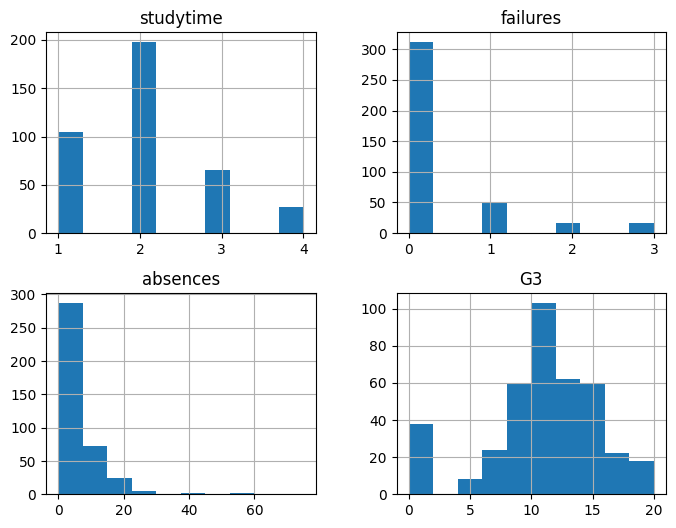

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(8,6))
plt.show()

vii) Correlation

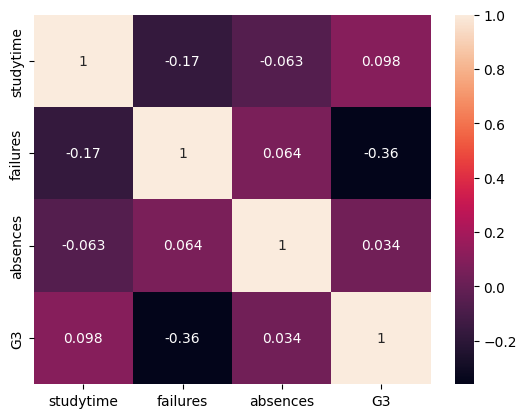

In [ ]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True)
plt.show()

viii) Defining Features & Target

In [ ]:
X = df[['studytime', 'failures', 'absences']]
y = df['G3']

ix) Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

LINEAR REGRESSION

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

EVALUATION

In [ ]:
from sklearn.metrics import r2_score

print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))

Linear Regression R2: 0.03074152988683987
Random Forest R2: 0.09258107748314603


FINAL GRAPH

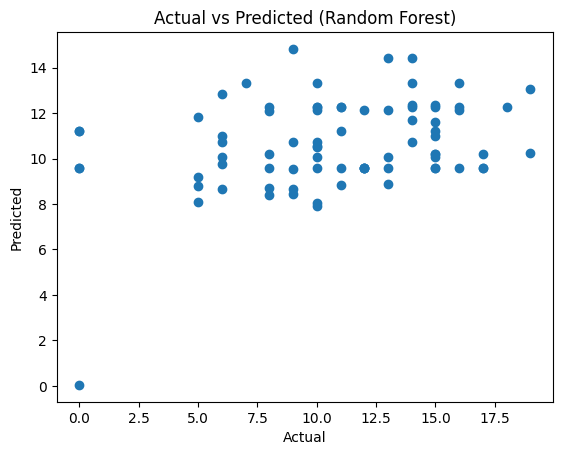

In [ ]:
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

FEATURE IMPORTANCE

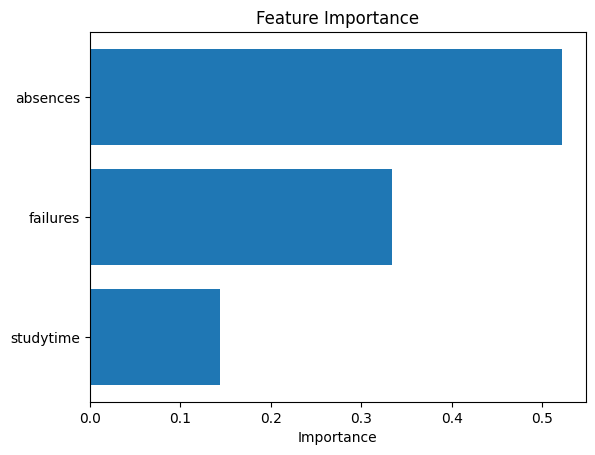

In [ ]:
importance = rf.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()